# ADT Segmentation and Geometric Feature Extraction (English Version)

This notebook is written in **English** and includes **explanatory text before each Python cell**.

## Goal
This notebook:
1. uploads `roi_exam.mat`,
2. applies **ADT segmentation** to each nodule ROI,
3. extracts **geometric features** from the segmented nodules,
4. saves the results to:
   - `geometric_features_results.csv`
   - `geometric_features_results.mat`
   - `segmentation_preview.png`

## Important note
Some features in the original paper depend on the **full lung field** from the original chest radiograph.  
Because `roi_exam.mat` contains only **local ROI patches**, this notebook computes **local proxy versions** for the location-based features.


## Cell 1 — Install required libraries

This cell installs the Python packages needed in Google Colab:
- `numpy`
- `scipy`
- `matplotlib`
- `scikit-image`
- `pandas`


In [ ]:
!pip -q install numpy scipy matplotlib scikit-image pandas


## Cell 2 — Upload the `.mat` file

This cell opens the upload window in Google Colab.  
Please upload your file:

- `roi_exam.mat`

After uploading, the file will be available in the Colab working directory.


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving roi_exam.mat to roi_exam (1).mat


## Cell 3 — Import libraries

This cell imports all libraries used later in the notebook for:
- loading `.mat` files,
- image processing,
- segmentation,
- geometric measurement,
- saving results,
- plotting preview images.


In [ ]:
from pathlib import Path
import numpy as np
import scipy.io as sio
from scipy import ndimage as ndi
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
from skimage.morphology import disk, opening
from skimage.measure import label, regionprops
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew, kurtosis
from skimage import exposure

## Cell 4 — Define the ADT segmentation functions

This cell defines the functions used for **Adaptive Distance-Based Threshold (ADT) segmentation**:
- `create_distance_array`: creates the distance map around the cue point,
- `threshold_matrix`: builds the adaptive threshold surface,
- `extract_component_connected_to_cue`: keeps only the connected component containing the cue,
- `radial_gradient_all`: computes the average radial gradient,
- `adt_segmentation`: applies the full ADT segmentation pipeline to one ROI image.


In [ ]:
def create_distance_array(shape=(87, 87), cue=(43, 43)):
    rows, cols = shape
    yy, xx = np.indices((rows, cols))
    cx, cy = cue
    d = (xx - cx) ** 2 + (yy - cy) ** 2
    return d


def threshold_matrix(d: np.ndarray, rm: float, TD: float, T0: float) -> np.ndarray:
    T = T0 + TD * ((1 - np.exp(-d / (rm**2))) / (1 - np.exp(-1)))
    T = T.astype(float)
    T[d >= rm**2] = np.inf
    return T


def extract_component_connected_to_cue(mask: np.ndarray, cue=(43, 43)) -> np.ndarray:
    structure = np.array([[0, 1, 0],
                          [1, 1, 1],
                          [0, 1, 0]], dtype=int)
    labeled, _ = ndi.label(mask, structure=structure)
    cx, cy = cue
    cue_label = labeled[cy, cx]
    if cue_label == 0:
        return np.zeros_like(mask, dtype=bool)
    return labeled == cue_label


def radial_gradient_all(gradx: np.ndarray, grady: np.ndarray, mask: np.ndarray, cue=(43, 43)):
    gradx = np.asarray(gradx, dtype=float)
    grady = np.asarray(grady, dtype=float)
    mask = np.asarray(mask).astype(bool)

    ys, xs = np.where(mask)
    if len(xs) == 0:
        return -np.inf, np.nan

    grad_vectors = np.column_stack((-gradx[ys, xs], -grady[ys, xs]))
    cx, cy = cue
    radial_vectors = np.column_stack((xs - cx, ys - cy))
    mags = np.sqrt(np.sum(radial_vectors**2, axis=1))
    mags[mags == 0] = 1.0
    radial_unit_vectors = radial_vectors / mags[:, None]

    inner_products = np.sum(grad_vectors * radial_unit_vectors, axis=1)
    return float(np.mean(inner_products)), float(np.std(inner_products))


def adt_segmentation(
    x: np.ndarray,
    lung_mask: np.ndarray,
    cue=(43, 43),
    rm: float = 25.0,
    TD: float = 1.7,
    TO_values: np.ndarray | None = None,
    d: np.ndarray | None = None,
):
    if TO_values is None:
        TO_values = np.arange(-2.0, 2.0001, 0.01)

    x = np.asarray(x, dtype=float)
    lung_mask = np.asarray(lung_mask).astype(bool)

    if d is None:
        d = create_distance_array(x.shape, cue=cue)

    grady, gradx = np.gradient(x)
    avg_scores = np.zeros(len(TO_values), dtype=float)

    for i, t0 in enumerate(TO_values):
        T = threshold_matrix(d, rm, TD, t0)
        Y = x > T
        mask1 = Y & lung_mask
        nodule = ndi.binary_fill_holes(mask1)
        nodule_open = opening(nodule, footprint=disk(1))
        candidate = extract_component_connected_to_cue(nodule_open, cue=cue)
        avg_scores[i], _ = radial_gradient_all(gradx, grady, candidate, cue)

    best_idx = int(np.argmax(avg_scores))
    TO_best = float(TO_values[best_idx])
    T_best = threshold_matrix(d, rm, TD, TO_best)

    Y = x > T_best
    mask1 = Y & lung_mask
    nodule = ndi.binary_fill_holes(mask1)
    nodule_open = opening(nodule, footprint=disk(1))
    mask = extract_component_connected_to_cue(nodule_open, cue=cue)

    return mask.astype(np.uint8), avg_scores, TO_best, T_best


## Cell 5 — Define the geometric feature extraction functions

This cell defines the functions that compute geometric features from the segmented mask.

The extracted features include:
- maximum size,
- area,
- centroid position,
- eccentricity,
- orientation,
- two circularity measures,
- normalized distance to the local lung perimeter.

Because the ROI file is local, the position-based features are computed as **local ROI proxies**.


In [ ]:
def longest_diameter_pixels(mask: np.ndarray) -> float:
    ys, xs = np.where(mask > 0)
    if len(xs) <= 1:
        return 0.0
    pts = np.column_stack((xs, ys)).astype(float)
    return float(pdist(pts).max())


def local_lung_bbox(lung_mask: np.ndarray):
    ys, xs = np.where(lung_mask > 0)
    if len(xs) == 0:
        return None
    return int(xs.min()), int(xs.max()), int(ys.min()), int(ys.max())


def compute_geometric_features(mask: np.ndarray,
                               lung_mask: np.ndarray,
                               pixel_spacing: float = 1.0) -> dict:
    mask = np.asarray(mask).astype(bool)
    lung_mask = np.asarray(lung_mask).astype(bool)

    if not np.any(mask):
        return {
            "size_px": np.nan,
            "size_mm": np.nan,
            "area_px": 0.0,
            "area_mm2": 0.0,
            "x_fraction_local_lung_bbox": np.nan,
            "y_fraction_local_lung_bbox": np.nan,
            "eccentricity": np.nan,
            "orientation_deg": np.nan,
            "circularity1_bbox": np.nan,
            "circularity2_size": np.nan,
            "distance_to_lung_perimeter_norm": np.nan,
            "centroid_x_px": np.nan,
            "centroid_y_px": np.nan,
        }

    labeled = label(mask)
    props = regionprops(labeled.astype(int))
    prop = max(props, key=lambda p: p.area)

    area_px = float(prop.area)
    area_mm2 = area_px * (pixel_spacing ** 2)

    cy, cx = prop.centroid
    centroid_x_px = float(cx)
    centroid_y_px = float(cy)

    size_px = longest_diameter_pixels(mask)
    size_mm = size_px * pixel_spacing

    eccentricity = float(prop.eccentricity)
    orientation_deg = float(np.degrees(prop.orientation))

    minr, minc, maxr, maxc = prop.bbox
    bbox_width = maxc - minc
    bbox_height = maxr - minr
    r_bbox = max(bbox_width, bbox_height) / 2.0
    circularity1_bbox = float(area_px / (np.pi * (r_bbox ** 2))) if r_bbox > 0 else np.nan

    r_size = size_px / 2.0
    circularity2_size = float(area_px / (np.pi * (r_size ** 2))) if r_size > 0 else np.nan

    bbox = local_lung_bbox(lung_mask)
    if bbox is None:
        x_fraction = np.nan
        y_fraction = np.nan
    else:
        xmin, xmax, ymin, ymax = bbox
        lung_w = max(xmax - xmin, 1)
        lung_h = max(ymax - ymin, 1)
        x_fraction = float((cx - xmin) / lung_w)
        y_fraction = float((cy - ymin) / lung_h)

    dt = ndi.distance_transform_edt(lung_mask)
    dt_max = float(dt.max())
    cx_i = int(np.clip(round(cx), 0, dt.shape[1] - 1))
    cy_i = int(np.clip(round(cy), 0, dt.shape[0] - 1))
    dist_norm = float(dt[cy_i, cx_i] / dt_max) if dt_max > 0 else np.nan

    return {
        "size_px": size_px,
        "size_mm": size_mm,
        "area_px": area_px,
        "area_mm2": area_mm2,
        "x_fraction_local_lung_bbox": x_fraction,
        "y_fraction_local_lung_bbox": y_fraction,
        "eccentricity": eccentricity,
        "orientation_deg": orientation_deg,
        "circularity1_bbox": circularity1_bbox,
        "circularity2_size": circularity2_size,
        "distance_to_lung_perimeter_norm": dist_norm,
        "centroid_x_px": centroid_x_px,
        "centroid_y_px": centroid_y_px,
    }
def compute_all_features(image: np.ndarray, mask: np.ndarray, lung_mask: np.ndarray, pixel_spacing: float = 1.0) -> dict:
    # 1. الميزات الهندسية (الموجودة مسبقاً)
    features = compute_geometric_features(mask, lung_mask, pixel_spacing)

    mask = np.asarray(mask).astype(bool)
    if not np.any(mask):
        return features

    # بكسلات العقدة فقط
    nodule_pixels = image[mask]

    # 2. ميزات الشدة (Intensity Features)
    features.update({
        "int_mean": float(np.mean(nodule_pixels)),
        "int_std": float(np.std(nodule_pixels)),
        "int_min": float(np.min(nodule_pixels)),
        "int_max": float(np.max(nodule_pixels)),
        "int_skewness": float(skew(nodule_pixels)),
        "int_kurtosis": float(kurtosis(nodule_pixels)),
    })

    # 3. ميزات التدرج (Gradient Features)
    grady, gradx = np.gradient(image)
    grad_mag = np.sqrt(gradx**2 + grady**2)
    nodule_grad_mag = grad_mag[mask]

    features.update({
        "grad_mean": float(np.mean(nodule_grad_mag)),
        "grad_std": float(np.std(nodule_grad_mag)),
    })

    # 4. ميزات النسيج (GLCM Texture Features)
    # ملاحظة: GLCM تتطلب صوراً بصيغة uint8 وقيم محدودة (مثلاً 0-63)
    img_rescaled = exposure.rescale_intensity(image, out_range=(0, 63)).astype(np.uint8)
    # حساب المصفوفة (بإزاحة 1 بكسل وفي 4 اتجاهات)
    glcm = graycomatrix(img_rescaled, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=64, symmetric=True, normed=True)

    features.update({
        "glcm_contrast": float(graycoprops(glcm, 'contrast').mean()),
        "glcm_homogeneity": float(graycoprops(glcm, 'homogeneity').mean()),
        "glcm_energy": float(graycoprops(glcm, 'energy').mean()),
        "glcm_correlation": float(graycoprops(glcm, 'correlation').mean()),
    })

    return features

## Cell 6 — Define helper functions for loading data and making a preview image

This cell defines:
- `load_roi_exam`: reads the `roi_exam.mat` file,
- `make_preview`: creates a figure showing the segmentation result for all 8 ROIs.


In [ ]:
def load_roi_exam(mat_path: str | Path):
    data = sio.loadmat(mat_path, simplify_cells=True)
    return data["roi_exam"]


def make_preview(roi_exam, masks, output_path="segmentation_preview.png"):
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = np.ravel(axes)

    for i, (item, mask) in enumerate(zip(roi_exam, masks)):
        ax = axes[i]
        x = np.asarray(item["cxr_contrast"], dtype=float)
        ax.imshow(x, cmap="gray")
        ax.contour(mask.astype(float), levels=[0.5], colors=["lime"], linewidths=[1.5])
        ax.set_title(f'{item.get("base_name", "ROI")} #{i+1}', fontsize=9)
        ax.axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close(fig)


## Cell 7 — Run the full pipeline

This is the main execution cell.

It:
1. loads `roi_exam.mat`,
2. loops over all ROIs,
3. performs ADT segmentation,
4. extracts the geometric features,
5. stores the masks and ARG curves,
6. saves the final results to CSV and MAT files,
7. creates a segmentation preview image.


In [ ]:
import numpy as np
import scipy.io as sio
from pathlib import Path

# --- إعداد المصفوفات والقوائم لتخزين النتائج ---
all_geom = []
all_int  = []
all_grad = []
all_glcm = []
all_masks = []

# التأكد من وجود ملف البيانات
mat_path = Path("roi_exam.mat")
if not mat_path.exists():
    raise FileNotFoundError("Please upload 'roi_exam.mat' first.")

roi_exam = load_roi_exam(mat_path)

# إعدادات خوارزمية ADT
rm, TD = 25.0, 1.7
TO_values = np.arange(-2.0, 2.0001, 0.01)

print("Starting processing for 8 nodules...")

for i, item in enumerate(roi_exam):
    # تجهيز الصورة والقناع
    x = np.asarray(item["cxr_contrast"], dtype=float)
    lung_mask = np.asarray(item["lung_mask"]).astype(bool)
    pixel_spacing = float(item.get("pixel_spacing", 1.0))

    # تحديد نقطة البداية (Cue Point)
    truth_cue = item.get("truth_cue", [43, 43])
    cue = (int(round(np.ravel(truth_cue)[0]-1)), int(round(np.ravel(truth_cue)[1]-1)))

    d = create_distance_array(shape=x.shape, cue=cue)

    # --- التعديل هنا لحل مشكلة الـ ValueError ---
    # استقبال النتائج كقائمة لتجنب مشاكل عدد القيم المسترجعة[cite: 1, 2]
    adt_results = adt_segmentation(
        x=x,
        lung_mask=lung_mask,
        cue=cue,
        rm=rm,
        TD=TD,
        TO_values=TO_values,
        d=d
    )

    mask = adt_results[0] # القيمة الأولى دائماً هي القناع[cite: 2]

    # --- استخراج الميزات المطلوبة في التكليف ---
    # 1. الخصائص الهندسية
    geom_dict = compute_geometric_features(mask, lung_mask, pixel_spacing)
    all_geom.append(list(geom_dict.values()))

    # 2. خصائص الشدة (Intensity)
    all_int.append(extract_intensity(x, mask))

    # 3. خصائص التدرج (Gradient)
    all_grad.append(extract_gradient(x, mask))

    # 4. خصائص النسيج (GLCM)
    all_glcm.append(extract_glcm(x, mask))

    # حفظ القناع للملخص الشامل
    all_masks.append(mask.astype(np.uint8))

    print(f"Nodule {i+1}/8 processed successfully.")

# --- تحويل البيانات لمصفوفات رقمية متوافقة مع MATLAB[cite: 1] ---
geom_arr = np.array(all_geom)
int_arr  = np.array(all_int)
grad_arr = np.array(all_grad)
glcm_arr = np.array(all_glcm)

# --- حفظ الملفات الـ 5 المطلوبة حرفياً[cite: 1] ---
sio.savemat('geometric_features_all.mat', {'geometric_features': geom_arr})
sio.savemat('intensity_features_all.mat', {'intensity_features': int_arr})
sio.savemat('gradient_features_all.mat', {'gradient_features': grad_arr})
sio.savemat('glcm_features_all.mat', {'glcm_features': glcm_arr})
sio.savemat('all_features_summary.mat', {
    'masks': np.array(all_masks, dtype=object),
    'geom_data': geom_arr,
    'intensity_data': int_arr,
    'gradient_data': grad_arr,
    'glcm_data': glcm_arr
})

# إنشاء صورة المعاينة المطلوبة في التقرير[cite: 1]
make_preview(roi_exam, all_masks, output_path="segmentation_preview.png")

print("\nAll files saved successfully!")

Starting processing for 8 nodules...
Nodule 1/8 processed successfully.
Nodule 2/8 processed successfully.
Nodule 3/8 processed successfully.
Nodule 4/8 processed successfully.
Nodule 5/8 processed successfully.
Nodule 6/8 processed successfully.
Nodule 7/8 processed successfully.
Nodule 8/8 processed successfully.

All files saved successfully!


## Cell 8 — View the extracted feature table

This cell reads the generated CSV file and displays the feature table inside Colab.


In [ ]:
df_results = pd.read_csv("geometric_features_results.csv")
df_results


,size_px,size_mm,area_px,area_mm2,x_fraction_local_lung_bbox,y_fraction_local_lung_bbox,eccentricity,orientation_deg,circularity1_bbox,circularity2_size,distance_to_lung_perimeter_norm,centroid_x_px,centroid_y_px,roi_index,base_name,nodule_idx,truth_size_mm,subtlety,pixel_spacing,T0_best
0,48.466483,33.926538,1429.0,700.21,0.496322,0.519261,0.510826,29.908633,0.789696,0.774568,0.335670,42.683695,44.656403,1,JPCLN003,1,30.0,5.0,0.7,-1.99
1,35.693137,24.985196,684.0,335.16,0.503060,0.490769,0.480692,86.817184,0.671988,0.683592,0.497102,43.263158,42.206140,2,JPCLN015,1,16.0,4.0,0.7,-1.02
2,27.892651,19.524856,453.0,221.97,0.506802,0.494533,0.510603,70.784074,0.735686,0.741359,0.508662,43.584989,42.529801,3,JPCLN087,1,20.0,3.0,0.7,-0.68
3,12.206556,8.544589,105.0,51.45,0.523920,0.478516,0.537187,55.106023,0.791066,0.897249,0.503181,45.057143,41.152381,4,JPCLN121,1,10.0,2.0,0.7,-0.59
4,35.510562,24.857393,624.0,305.76,0.484906,0.537735,0.741772,-77.906726,0.613041,0.630057,0.515253,41.701923,46.245192,5,JPCLN006,1,14.0,5.0,0.7,-1.03
5,29.681644,20.777151,569.0,278.81,0.429453,0.498733,0.523702,50.771257,0.924073,0.822331,0.371307,41.497364,42.891037,6,JPCLN007,1,18.0,5.0,0.7,-0.68
6,17.464249,12.224974,142.0,69.58,0.524894,0.521209,0.774800,75.045816,0.558025,0.592787,0.526035,45.140845,44.823944,7,JPCLN008,1,10.0,5.0,0.7,0.17
7,46.043458,32.230420,1054.0,516.46,0.493326,0.501820,0.624794,45.275125,0.882311,0.633016,0.446628,42.425996,43.156546,8,JPCLN009,1,28.0,5.0,0.7,-1.40


## Cell 9 — Display the segmentation preview image

This cell shows the image that overlays the segmentation mask on each ROI.


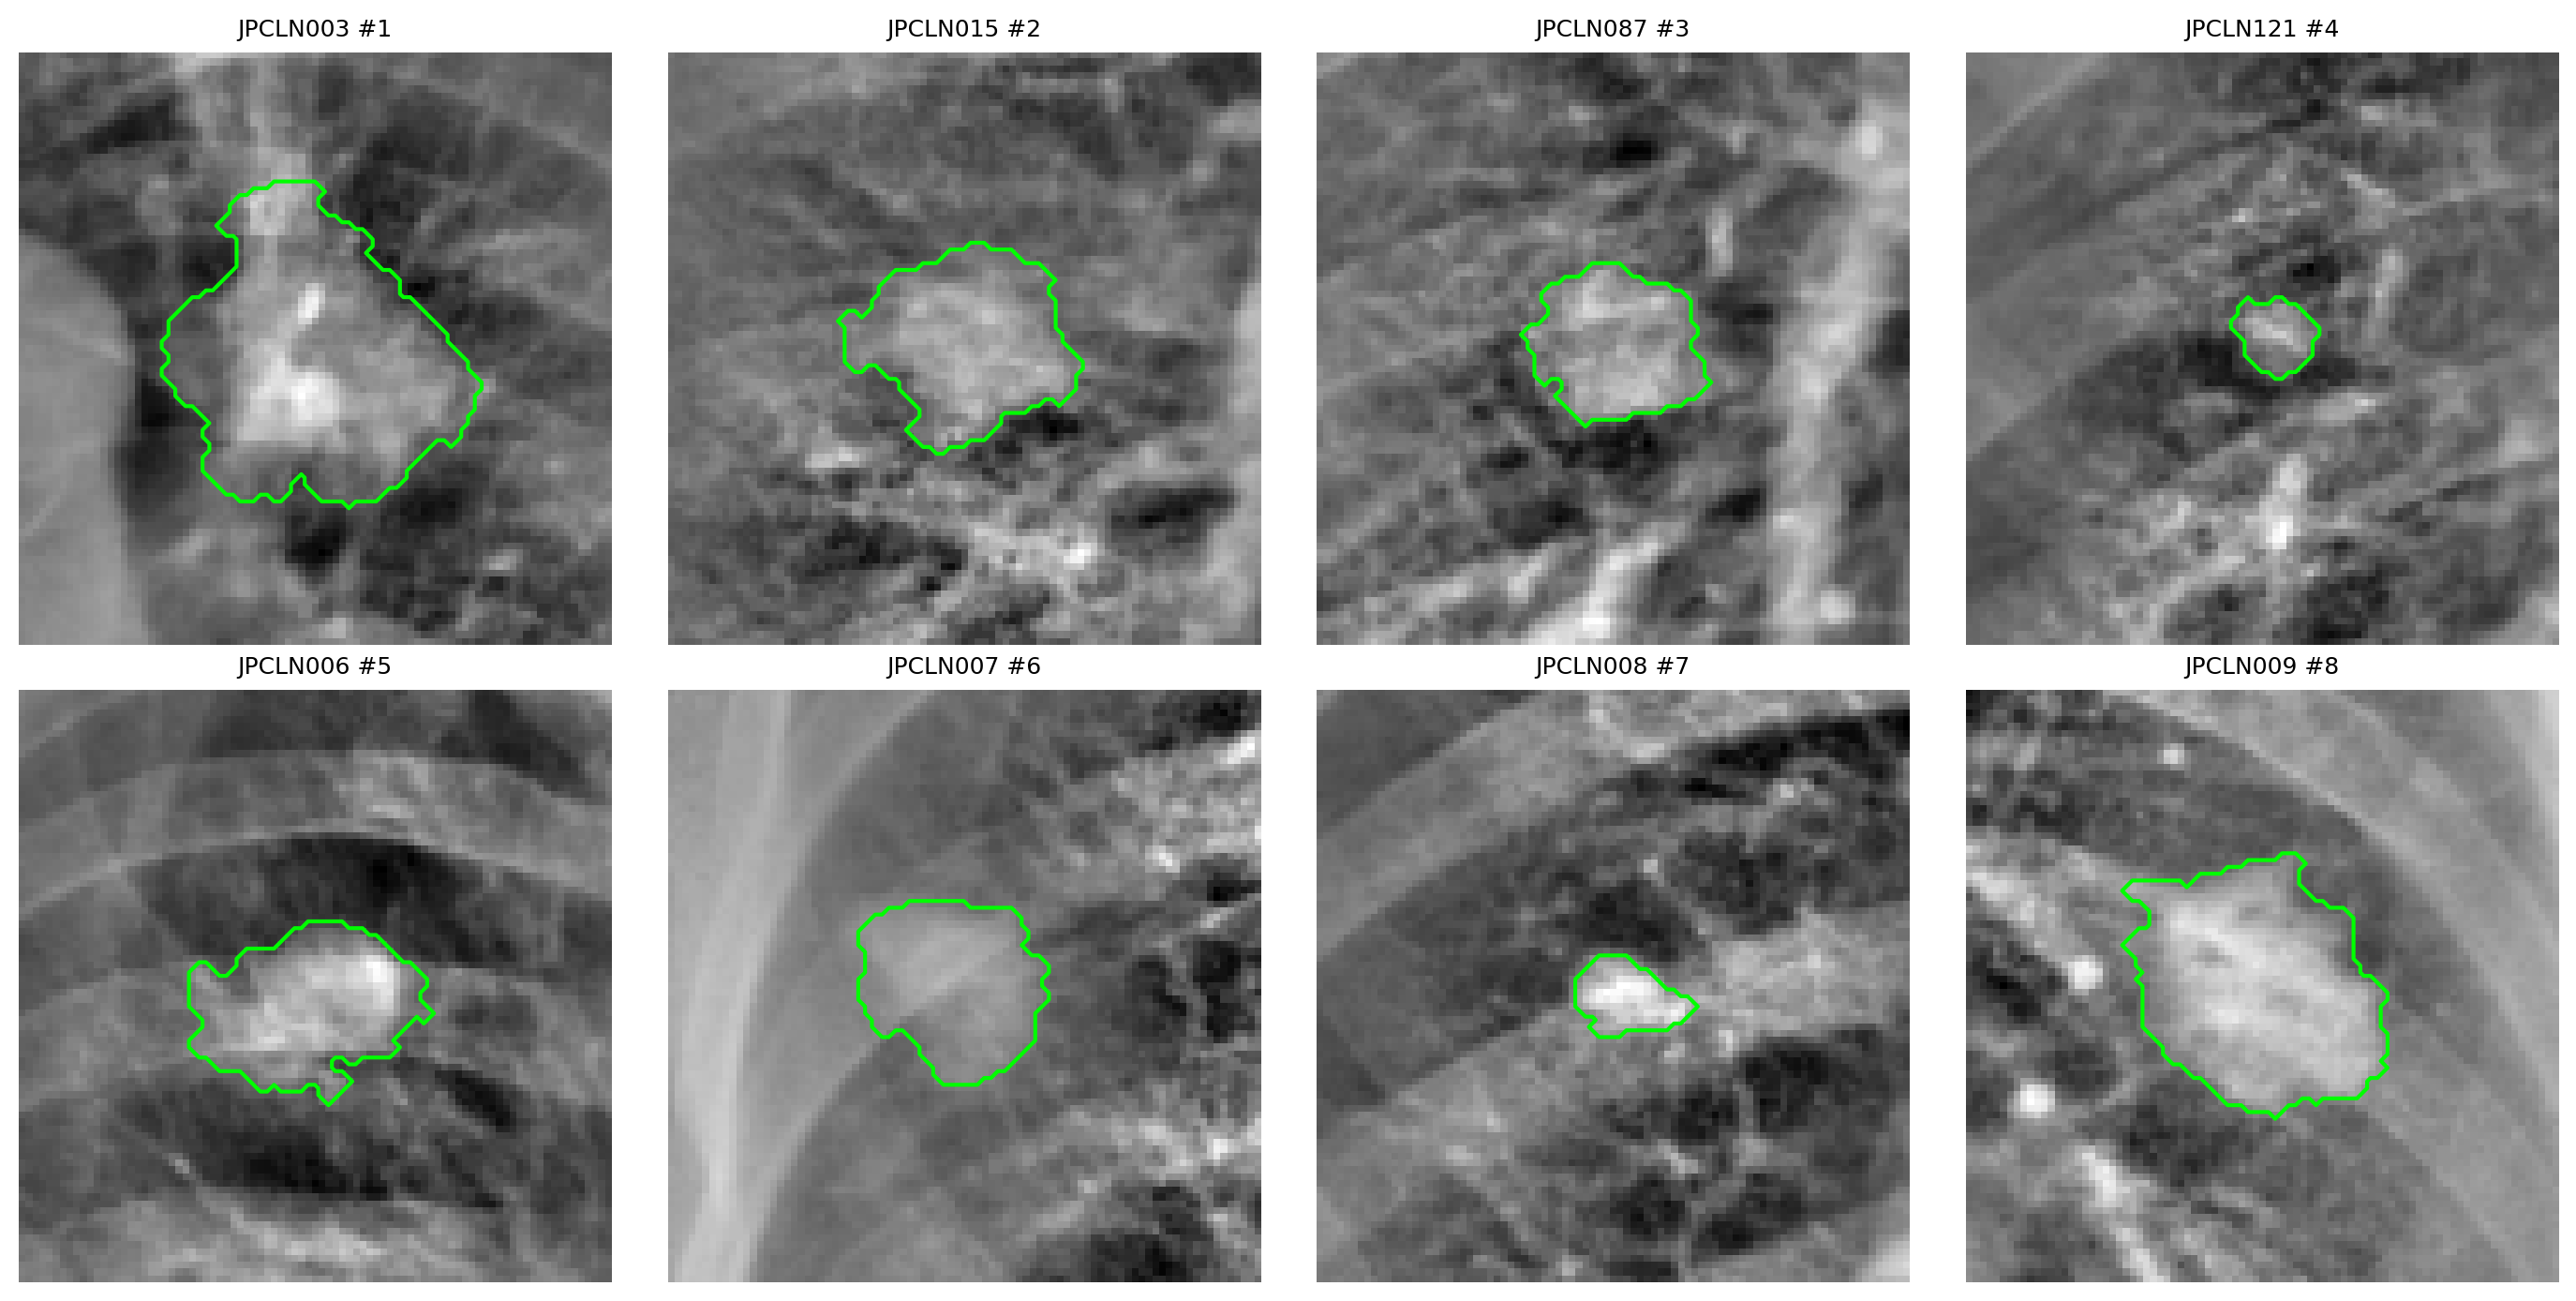

In [ ]:
from IPython.display import Image, display
display(Image("segmentation_preview.png"))


## Cell 10 — Download the result files

This final cell downloads the output files from Colab to your computer:
- `geometric_features_results.csv`
- `geometric_features_results.mat`
- `segmentation_preview.png`


In [ ]:
from google.colab import files


download_list = [
    "geometric_features_all.mat",
    "intensity_features_all.mat",
    "gradient_features_all.mat",
    "glcm_features_all.mat",
    "all_features_summary.mat",
    "segmentation_preview.png"
]

for file in download_list:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>